Adds several regularization techniques to improve training performance without adding any new training data.
* Scale inputs between 0 & 1
* Use dropout after maxpooling
* Use batchnorm between conv and activation
* Optionally add another VGG block
* Increase the width of various blocks, like channels in the conv units.
* Use a learning rate scheduler to reduce LR over time

With all changes, we get ~85.3%, up from ~70% in the baseline.

In [1]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
def transform(image):
    image = tvf.pil_to_tensor(image)
    image = image / 255
    return image

def onehot_label(cls: int):
    cls = torch.tensor(cls).long()
    return F.one_hot(cls, num_classes=11)

cifar_train = tds.CIFAR10(
    root='datasets',
    download=True,
    train=True,
    transform=transform,
    target_transform=onehot_label,
)

cifar_eval = tds.CIFAR10(
    root='datasets',
    download=True,
    train=False,
    transform=transform,
    target_transform=onehot_label,
)

Files already downloaded and verified
Files already downloaded and verified


In [3]:
batchsize = 32

train_loader = tud.DataLoader(cifar_train, batch_size=batchsize, shuffle=True)
val_loader = tud.DataLoader(cifar_eval, batch_size=batchsize, shuffle=True)

In [4]:
class MyCnn(nn.Module):
    def __init__(self, out_sz=10, ch=32):
        super().__init__()

        self.channels = ch
        self.out_sz = out_sz
        # (32x32)
        self.conv1_1 = nn.Conv2d(3, ch, kernel_size=3, stride=1, padding=1)
        self.bn1_1 = nn.BatchNorm2d(ch)
        self.conv1_2 = nn.Conv2d(ch, ch*2, kernel_size=3, stride=1, padding=1)
        self.bn1_2 = nn.BatchNorm2d(ch*2)

        # (16x16)
        self.conv2_1 = nn.Conv2d(ch*2, ch*2, kernel_size=3, stride=1, padding=1)
        self.bn2_1 = nn.BatchNorm2d(ch*2)
        self.conv2_2 = nn.Conv2d(ch*2, ch*4, kernel_size=3, stride=1, padding=1)
        self.bn2_2 = nn.BatchNorm2d(ch*4)
        
        # (8x8)
        self.conv3_1 = nn.Conv2d(ch*4, ch*4, kernel_size=3, stride=1, padding=1)
        self.bn3_1 = nn.BatchNorm2d(ch*4)
        self.conv3_2 = nn.Conv2d(ch*4, ch*8, kernel_size=3, stride=1, padding=1)
        self.bn3_2 = nn.BatchNorm2d(ch*8)
        
        self.lin1 = nn.Linear((ch*8) * 4 * 4, 128, bias=True)
        self.lin2 = nn.Linear(128, out_sz, bias=True)

    def forward(self, x):
        x = self.conv1_1(x)
        x = self.bn1_1(x)
        x = F.relu(x)
        x = self.conv1_2(x)
        x = self.bn1_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        x = F.dropout(x, p=0.1)

        x = self.conv2_1(x)
        x = self.bn2_1(x)
        x = F.relu(x)
        x = self.conv2_2(x)
        x = self.bn2_2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        x = F.dropout(x, p=0.15)

        x = self.conv3_1(x)
        x = self.bn3_1(x)
        x = F.relu(x)
        x = self.conv3_2(x)
        x = self.bn3_2(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.2)
        x = F.max_pool2d(x, kernel_size=2)
        
        x = x.view(-1, (self.channels*8) * 4 * 4)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.softmax(x, dim=-1)
        return x
        

In [5]:
from torchinfo import summary
testmodel = MyCnn(out_sz=11, ch=64)
summary(testmodel, (batchsize, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
MyCnn                                    [32, 11]                  --
├─Conv2d: 1-1                            [32, 64, 32, 32]          1,792
├─BatchNorm2d: 1-2                       [32, 64, 32, 32]          128
├─Conv2d: 1-3                            [32, 128, 32, 32]         73,856
├─BatchNorm2d: 1-4                       [32, 128, 32, 32]         256
├─Conv2d: 1-5                            [32, 128, 16, 16]         147,584
├─BatchNorm2d: 1-6                       [32, 128, 16, 16]         256
├─Conv2d: 1-7                            [32, 256, 16, 16]         295,168
├─BatchNorm2d: 1-8                       [32, 256, 16, 16]         512
├─Conv2d: 1-9                            [32, 256, 8, 8]           590,080
├─BatchNorm2d: 1-10                      [32, 256, 8, 8]           512
├─Conv2d: 1-11                           [32, 512, 8, 8]           1,180,160
├─BatchNorm2d: 1-12                      [32, 512, 

2.121958017349243
2.0372633934020996
2.0025908946990967
2.024568557739258
1.9440991878509521
1.913928508758545
1.8461929559707642
1.834196925163269
1.8090718984603882
1.8122390508651733
1.7867339849472046
1.790734052658081
1.7791547775268555
1.7734862565994263
1.764237403869629
1.7560497522354126
1.757759690284729
1.7491549253463745
1.7452374696731567
1.7516311407089233
1.7389593124389648
1.744417667388916
1.742979645729065
1.7296189069747925
1.7340792417526245
1.7303622961044312
1.724127173423767
1.7319817543029785
1.7242729663848877
1.7264591455459595
1.732391119003296
1.7255555391311646
1.7228995561599731
1.7178701162338257
1.7232133150100708
1.7223771810531616
1.7129415273666382
1.7141355276107788
1.715855598449707
1.7154055833816528
1.7153273820877075
1.7191015481948853
1.713845133781433
1.7092616558074951
1.7055020332336426
1.7107856273651123
1.7075234651565552
1.7168910503387451
1.711464762687683
1.7097750902175903
1.7124290466308594
1.7067582607269287
1.7112025022506714
1.70794

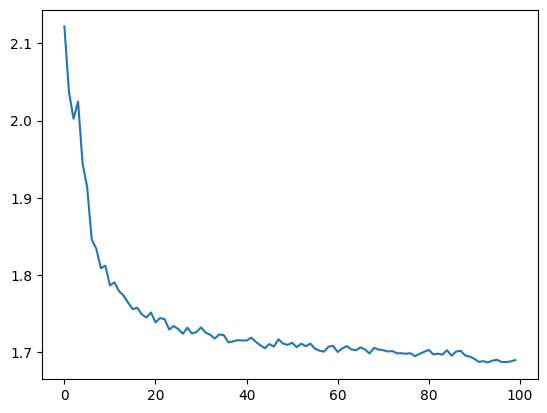

In [15]:
%%time
device='cuda'
model = MyCnn(out_sz=11, ch=32).to(device).train()

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', verbose=True)
lossfn = nn.CrossEntropyLoss()
epochs = 100

loss_plot = []
for epoch in range(epochs):
    model.train()
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.float().to(device)

        outs = model(images)
        loss = lossfn(outs, targets.view(-1, 11))
        loss.backward()
        optimizer.step()

    losses = []
    model.eval()
    for i, (images, target) in enumerate(val_loader):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.float().to(device)
            outs = model(images)

            loss = lossfn(outs, targets.view(-1, 11))
            losses.append(loss)
                
    epoch_loss = torch.Tensor(losses).mean().item()
    print(epoch_loss)
    loss_plot.append(epoch_loss)
    scheduler.step(epoch_loss)

plt.plot(loss_plot)

In [16]:
total = len(cifar_eval)
correct = 0
model.eval()
with torch.no_grad():
    for image, target in cifar_eval:
        pred = model(image.unsqueeze(0).float().to(device))
        if torch.allclose(pred.round().long().cpu(), target.cpu()):
            correct += 1
        
    print("{:.2f}% correct".format(100*correct/total))

85.30% correct
